In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

This notebook benchmarks isoform aware depletion to a guide panel that removes 4,500 highly expressed genes in fibroblasts 
-
The key difference is that the 4,500 depletion panel targets entire gene loci versus just highly expressed read contigs, thus removing all isoforms for a targeted gene 

In [ ]:
#generation of count matrix for input into DESeq2
d1 = pd.read_csv('NEW_guide_analysis_GREGOR/c1_G2_WM_control_S4.isoforms.results', sep="\t")
d1 = d1.set_index('transcript_id')
d2 = pd.read_csv('NEW_guide_analysis_GREGOR/c1_G2_WM_DEH_S3.isoforms.results', sep="\t")
d2 = d2.set_index('transcript_id')
d3 = pd.read_csv('NEW_guide_analysis_GREGOR/e1_H4_WM_control_S6.isoforms.results', sep="\t")
d3 = d3.set_index('transcript_id')
d4 = pd.read_csv('NEW_guide_analysis_GREGOR/e1_H4_WM_DEH_S4.isoforms.results', sep="\t")
d4 = d4.set_index('transcript_id')

combine = pd.DataFrame()
combine['control_1'] = d1['expected_count']
combine['depleted_1'] = d2['expected_count']
combine['control_2'] = d3['expected_count']
combine['depleted_2'] = d4['expected_count']
combine.to_csv('NEW_guide_analysis_GREGOR/fig2_isoform_TPMs_control_DEH.txt', sep="\t")

compare general isoform TPMs
-
two biological replicates for each condition

In [2]:
d1 = pd.read_csv('NEW_guide_analysis_GREGOR/c1_G2_WM_control_S4.isoforms.results', sep="\t")
d1 = d1.set_index('transcript_id')
d2 = pd.read_csv('NEW_guide_analysis_GREGOR/c1_G2_WM_DEH_S3.isoforms.results', sep="\t")
d2 = d2.set_index('transcript_id')
d3 = pd.read_csv('NEW_guide_analysis_GREGOR/e1_H4_WM_control_S6.isoforms.results', sep="\t")
d3 = d3.set_index('transcript_id')
d4 = pd.read_csv('NEW_guide_analysis_GREGOR/e1_H4_WM_DEH_S4.isoforms.results', sep="\t")
d4 = d4.set_index('transcript_id')

combine = pd.DataFrame()
combine['control_1'] = d1['TPM']
combine['depleted_1'] = d2['TPM']
combine['control_2'] = d3['TPM']
combine['depleted_2'] = d4['TPM']
combine

,control_1,depleted_1,control_2,depleted_2
transcript_id,,,,
ENST00000373020.9,0.02,0.15,0.06,0.22
ENST00000494424.1,0.00,0.00,0.00,0.00
ENST00000496771.5,0.00,0.00,0.00,0.08
ENST00000612152.4,0.00,0.00,0.00,0.00
ENST00000614008.4,0.00,0.00,0.00,0.00
...,...,...,...,...
ENST00000690561.1,0.56,0.87,0.12,0.37
ENST00000687847.1,0.05,0.11,0.00,0.00
ENST00000688979.1,0.49,1.74,0.27,0.69


In [3]:
#check the total isoforms above TPM of 1
print("Control 1 >1 TPM:", sum(combine['control_1']>1))
print("Depleted 1 >1 TPM:", sum(combine['depleted_1']>1))
print("Control 2 >1 TPM:", sum(combine['control_2']>1))
print("Depleted 2 >1 TPM:", sum(combine['depleted_2']>1))

Control 1 >1 TPM: 29621
Depleted 1 >1 TPM: 46041
Control 2 >1 TPM: 31335
Depleted 2 >1 TPM: 44134


In [6]:
def plot_isoform_threshold_bars(combine: pd.DataFrame,
                                thresholds=(0.1, 1, 10),
                                title="Isoforms ≥ TPM threshold", 
                                save=False, 
                                savefile="GREGOR_GUIDE/figures/isoform_thresholds.png"):
    """
    combine: DataFrame with columns: control_1, control_2, depleted_1, depleted_2
             index = transcript_id (not required, but typical)
    thresholds: iterable of TPM cutoffs
    """

    # safety checks
    required = ["control_1", "control_2", "depleted_1", "depleted_2"]
    missing = [c for c in required if c not in combine.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Helper to count >= threshold per column
    def count_ge(col, t):
        return (combine[col] >= t).sum()

    # Combined = union within replicate pair
    def count_union_pair(cols, t):
        # union across the two columns at this threshold
        return ((combine[cols].max(axis=1) >= t).sum())

    # Build per-threshold replicate counts
    records = []
    for t in thresholds:
        # Control replicates
        ctrl_rep1 = count_ge("control_1", t)
        ctrl_rep2 = count_ge("control_2", t)

        # Depleted replicates
        dep_rep1 = count_ge("depleted_1", t)
        dep_rep2 = count_ge("depleted_2", t)

        # Combined replicates (pair 1 = control_1 ∨ depleted_1; pair 2 = control_2 ∨ depleted_2)
        comb_rep1 = count_union_pair(["control_1", "depleted_1"], t)
        comb_rep2 = count_union_pair(["control_2", "depleted_2"], t)

        # Store replicate-level rows (useful for later inspection)
        records += [
            {"threshold": t, "condition": "Standard",  "replicate": "rep1", "count": ctrl_rep1},
            {"threshold": t, "condition": "Standard",  "replicate": "rep2", "count": ctrl_rep2},
            {"threshold": t, "condition": "Depleted", "replicate": "rep1", "count": dep_rep1},
            {"threshold": t, "condition": "Depleted", "replicate": "rep2", "count": dep_rep2},
            {"threshold": t, "condition": "Combined", "replicate": "rep1", "count": comb_rep1},
            {"threshold": t, "condition": "Combined", "replicate": "rep2", "count": comb_rep2},
        ]

    df_counts = pd.DataFrame.from_records(records)

    # Aggregate to mean and std across replicates for error bars
    summary = (df_counts
               .groupby(["threshold", "condition"])["count"]
               .agg(mean="mean", sd=lambda x: np.std(x, ddof=1) if len(x) > 1 else 0.0)
               .reset_index())
    # Define custom colors for conditions
    colors = {
        "Standard": "lightgrey",   # blue
        "Depleted": "#4F5D2F",  # orange
        "Combined": "#A6C48A"   # green
    }

    # ---- Plot (matplotlib; single axes; no custom colors) ----
    conditions = ["Standard", "Depleted", "Combined"]
    xvals = list(thresholds)
    x_index = np.arange(len(xvals))
    width = 0.22  # bar width (3 bars per threshold)

    fig, ax = plt.subplots(figsize=(5, 6), dpi=120)

    for i, cond in enumerate(conditions):
        m = summary[summary["condition"] == cond].sort_values("threshold")
        xpos = x_index + (i - 1) * width  # center 3 bars around each threshold tick
        ax.bar(xpos, m["mean"].to_numpy(), width, yerr=m["sd"].to_numpy(),
               capsize=4, label=cond, color=colors[cond], edgecolor='black', linewidth=0.5)
        
    # Add connecting lines + percent increase text
    for i, t in enumerate(thresholds):
        std_mean = summary.query("threshold == @t and condition == 'Standard'")["mean"].values[0]
        comb_mean = summary.query("threshold == @t and condition == 'Combined'")["mean"].values[0]
        if std_mean == 0:
            continue

        pct_increase = (comb_mean - std_mean) / std_mean * 100
        x_comb = x_index[i] + width  # Combined bar position
        line_x = x_comb + width * 0.8  # place line just to right of combined bar

        # vertical line
        ax.plot([line_x, line_x], [std_mean, comb_mean],
                color="forestgreen", linewidth=1.5, alpha=0.8)

        # centered text to right of line
        mid_y = (std_mean + comb_mean) / 2
        ax.text(line_x + 0.05, mid_y, f"{pct_increase:+.0f}%",
                va="center", ha="left", fontsize=12, color="black")
        
    #remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x_index)
    ax.set_xticklabels([str(t) for t in xvals])
    ax.set_xlabel("TPM threshold", fontsize=18)
    ax.set_ylabel("# Unique Isoforms ≥ threshold", fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig(savefile, dpi=300)
    plt.show()

    return df_counts, summary

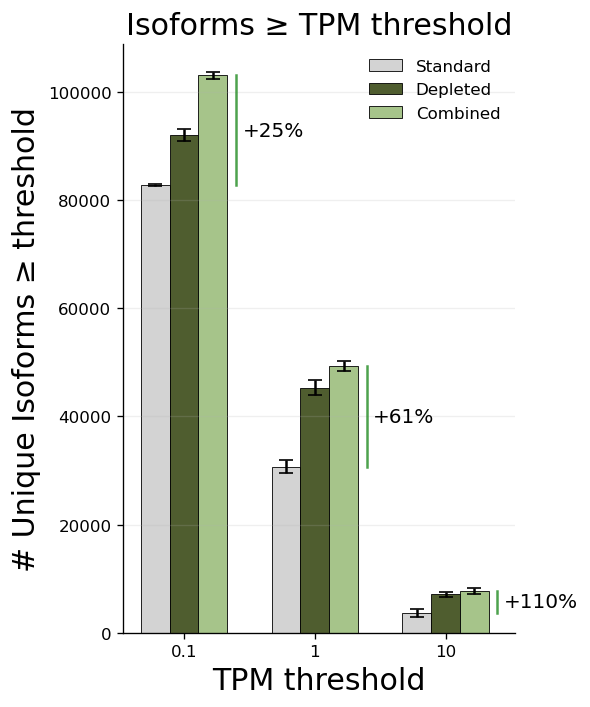

In [7]:
df_counts, summary = plot_isoform_threshold_bars(combine, 
                                                 save=True,
                                                 savefile="GREGOR_GUIDE/figures/isoform_thresholds.png")

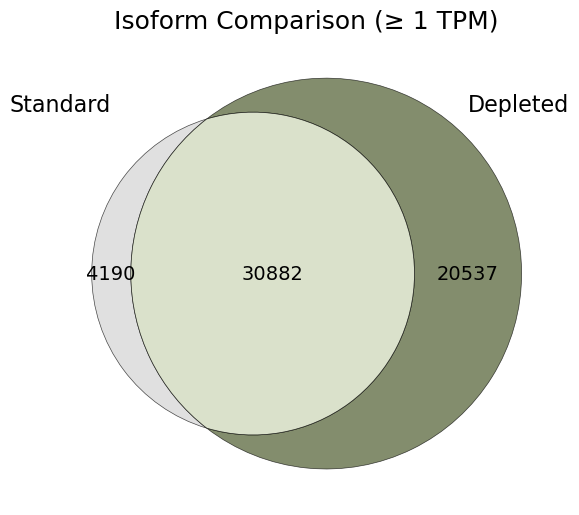

In [ ]:
# compare the actual isoforms recovered 
standard1 = combine[combine['control_1']>=1].index.tolist()
standard2 = combine[combine['control_2']>=1].index.tolist()
depleted1 = combine[combine['depleted_1']>=1].index.tolist()
depleted2 = combine[combine['depleted_2']>=1].index.tolist()

standard = set(standard1).union(set(standard2))
depleted = set(depleted1).union(set(depleted2))

from matplotlib_venn import venn2
plt.figure(figsize=(6,6))  

v = venn2([standard, depleted],
          set_labels=('Standard', 'Depleted'),
          set_colors=('lightgrey', '#4F5D2F'),
          alpha=0.7)

# --- Outline all Venn patches with black borders ---
for patch in v.patches:
    if patch is not None:
        patch.set_edgecolor("black")
        patch.set_linewidth(0.5)

for label in v.subset_labels:
    if label is not None:
        label.set_fontsize(14)

if v.get_label_by_id('10'):
    c1 = v.get_label_by_id('10').get_position()[0]
else:
    c1 = -0.15
if v.get_label_by_id('01'):
    c2 = v.get_label_by_id('01').get_position()[0]
else:
    c2 = 0.15

# Set new label positions
v.set_labels[0].set_position((c1, 0.5))  
v.set_labels[1].set_position((c2, 0.5))  

# Adjust label appearance
for label in v.set_labels:
    label.set_fontsize(16)
    label.set_color("black")
    
# --- Title and layout tweaks ---
plt.title("Isoform Comparison (≥ 1 TPM)", fontsize=18, pad=10)
plt.tight_layout()
plt.savefig("GREGOR_GUIDE/figures/isoform_venn_diagram.png", dpi=600, bbox_inches='tight')
plt.show()

Analyze the output of DESeq2 paired design
-
Each standard and depleted matched library represents the same underlying RNA

In [10]:
data = pd.read_csv('NEW_guide_analysis_GREGOR/deseq2_isoforms_control_DEH_n2.csv', index_col=0)
data = data.dropna(subset=['log2FoldChange'])
data = data.sort_values(by='log2FoldChange', ascending=False)
data

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENST00000504342.5,4600.863515,15.447898,4.000879,3.861126,0.000113,0.000767
ENST00000575659.6,3629.028080,15.138822,4.000882,3.783871,0.000154,0.001021
ENST00000453303.5,3070.230586,14.863071,4.000886,3.714945,0.000203,0.001310
ENST00000560738.1,2818.507846,14.764117,4.000887,3.690211,0.000224,0.001432
ENST00000422373.6,2110.377246,14.351377,4.000894,3.587043,0.000334,0.002057
...,...,...,...,...,...,...
ENST00000681887.1,4358.823668,-15.648181,4.000892,-3.911173,0.000092,0.000636
ENST00000648898.1,4985.211048,-15.881332,4.000889,-3.969451,0.000072,0.000509
ENST00000520804.2,5345.004575,-15.962821,4.000888,-3.989819,0.000066,0.000471
ENST00000649452.1,5639.676399,-16.016333,4.000888,-4.003195,0.000062,0.000447


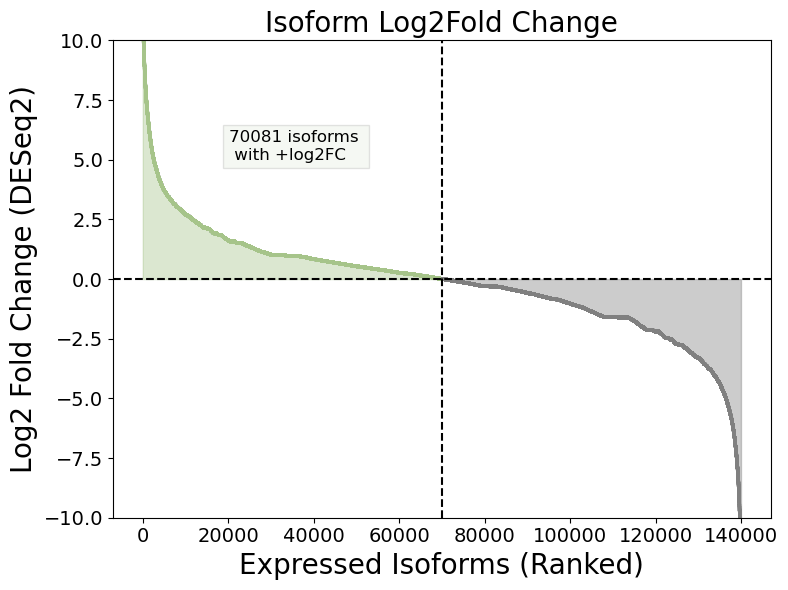

In [ ]:
sort_merged = data.copy()
sort_merged['OG_name'] = sort_merged.index
sort_merged = sort_merged.reset_index(drop=True)
sort_merged['Count']=sort_merged.index

sort_merged.plot.scatter(x='Count', y='log2FoldChange', s=2,legend=True,
                        c=np.where((sort_merged['log2FoldChange']>0), "#A6C48A", 'grey'), figsize=(8,6),
                            ylim=(-10,10), fontsize=14)

plt.title(f'Isoform Log2Fold Change', fontdict={'fontsize': 20,
    'verticalalignment': 'baseline',
    'horizontalalignment': 'center'})

plt.xlabel('Expressed Isoforms (Ranked)', fontdict={'fontsize': 20})
plt.ylabel('Log2 Fold Change (DESeq2)', fontdict={'fontsize': 20})

#just the positive differences
merged_pos = sort_merged[sort_merged['log2FoldChange']>0]
plt.fill_between(merged_pos.Count, merged_pos.log2FoldChange, step="pre", color="#A6C48A", alpha=0.4)
merged_neg = sort_merged[sort_merged['log2FoldChange']<0]
plt.fill_between(merged_neg.Count, merged_neg.log2FoldChange, step="pre", color='grey', alpha=0.4)
 
plt.axvline(x=len(merged_pos), color='black', linestyle='--')
plt.text(len(merged_pos)-50000, 5, str(len(merged_pos))+" isoforms \n with +log2FC", 
        fontsize = 12, 
        bbox = dict(facecolor = "#A6C48A", alpha = 0.1))

#add the average 
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/isoform_log2FC_control_DEH.png', dpi=300)
plt.show()  

saturn analysis - how the relative usage of isoforms changed 
-


In [12]:
df_D4500 = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_D4500.csv")
df_DAH = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DAH.csv")
df_DEH = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DEH.csv")

depleted = df_DEH['isoform_id'].tolist()
standard = df_D4500['isoform_id'].tolist()
combined = list(set(depleted).union(set(standard)))
combine = pd.DataFrame()
combine['isoform_id'] = combined
combine = combine.set_index('isoform_id')

df_D4500 = df_D4500.set_index('isoform_id')
df_DEH = df_DEH.set_index('isoform_id')

combine['standard_padj'] = df_D4500['padj']
combine['depleted_padj'] = df_DEH['padj']
combine['depleted_padj'] = combine['depleted_padj'].fillna(1)
combine['standard_padj'] = combine['standard_padj'].fillna(1)
combine = combine.rename(columns={'standard_padj': 'F4500', 'depleted_padj': 'Depleted'})
combine

,F4500,Depleted
isoform_id,,
ENST00000467659.1,0.249354,0.288457
ENST00000647167.1,0.714877,0.266954
ENST00000531676.1,0.098817,0.626701
ENST00000660188.1,0.209908,0.086561
ENST00000467351.1,0.383747,0.065638
...,...,...
ENST00000254521.8,0.947759,0.320423
ENST00000449538.3,0.584269,0.838996
ENST00000261735.4,0.604433,0.152196


In [ ]:
def plot_pval_threshold_bars(data: pd.DataFrame,
                             thresholds=(0.05, 0.01, 0.001),
                             title="Isoforms ≤ p-value threshold",
                             save=False,
                             savefile="GREGOR_GUIDE/figures/pval_thresholds.png"):
    """
    data: DataFrame with two columns (e.g. 'F4500', 'Depleted')
          index = isoform_id
    thresholds: p-value cutoffs to count below
    """

    # sanity check
    if data.shape[1] != 2:
        raise ValueError("Data must have exactly two columns (e.g. 'F4500' and 'Depleted').")
    cond1, cond2 = data.columns.tolist()

    # count below threshold
    records = []
    for t in thresholds:
        c1_count = (data[cond1] <= t).sum()
        c2_count = (data[cond2] <= t).sum()
        records += [
            {"threshold": t, "condition": cond1, "count": c1_count},
            {"threshold": t, "condition": cond2, "count": c2_count}
        ]

    df_counts = pd.DataFrame.from_records(records)

    # no replicates, so SD = 0
    df_counts["sd"] = 0
    summary = df_counts.rename(columns={"count": "mean"})

    # colors
    colors = {
        cond1: "lightgrey",   
        cond2: "#4F5D2F"     
    }

    # x-axis positions
    conditions = [cond1, cond2]
    xvals = list(thresholds)
    x_index = np.arange(len(xvals))
    width = 0.28

    fig, ax = plt.subplots(figsize=(5, 6), dpi=120)

    for i, cond in enumerate(conditions):
        m = summary[summary["condition"] == cond].sort_values("threshold", ascending=False)
        xpos = x_index + (i - 0.5) * width
        ax.bar(
            xpos,
            m["mean"].to_numpy(),
            width,
            yerr=m["sd"].to_numpy(),
            capsize=4,
            label=cond,
            color=colors[cond],
            edgecolor="black",
            linewidth=0.6
        )

    # add vertical line showing % increase of Depleted relative to F4500
    for i, t in enumerate(thresholds):
        c1_mean = summary.query("threshold == @t and condition == @cond1")["mean"].values[0]
        c2_mean = summary.query("threshold == @t and condition == @cond2")["mean"].values[0]
        if c1_mean == 0:
            continue
        pct_increase = (c2_mean - c1_mean) / c1_mean * 100
        x_c2 = x_index[i] + width / 2   # Depleted bar position
        line_x = x_c2 + width * 0.8

        ax.plot([line_x, line_x], [c1_mean, c2_mean],
                color="forestgreen", linewidth=1.5, alpha=0.8)

        mid_y = (c1_mean + c2_mean) / 2
        ax.text(line_x + 0.05, mid_y, f"{pct_increase:+.0f}%",
                va="center", ha="left", fontsize=12, color="black")

    #add the actual number counts on top of each bar
    for i, row in summary.iterrows():
        cond = row['condition']
        t = row['threshold']
        mean = row['mean']
        j = conditions.index(cond)
        xpos = x_index[list(thresholds).index(t)] + (j - 0.5) * width
        ax.text(xpos, mean + max(summary['mean'])*0.01, str(int(mean)),
                ha='center', va='bottom', fontsize=10, color='black')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x_index)
    ax.set_xticklabels([str(t) for t in xvals])
    ax.set_xlabel("q-value threshold", fontsize=16)
    ax.set_ylabel("# DTU ≤ threshold", fontsize=16)
    ax.set_title(title, fontsize=18)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    if save:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

    return summary

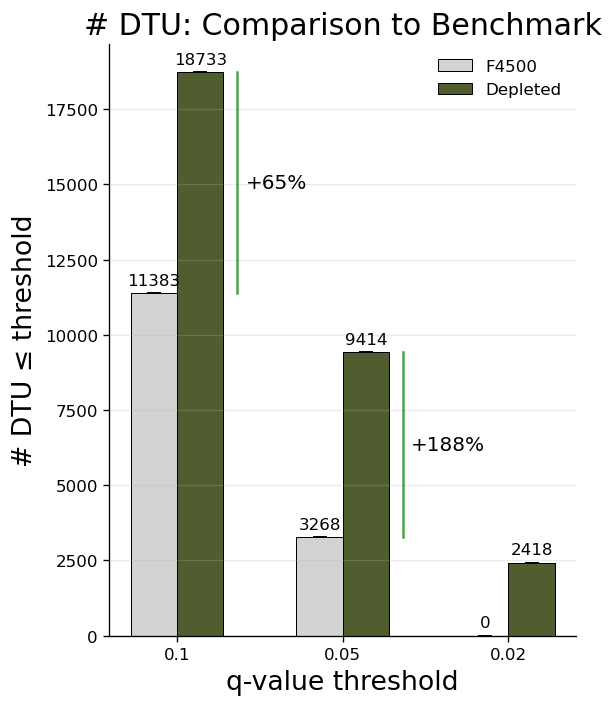

In [16]:
summary = plot_pval_threshold_bars(combine,
                             thresholds=(0.1, 0.05, 0.02),
                             title="# DTU: Comparison to Benchmark",
                             save=True,
                             savefile="GREGOR_GUIDE/figures/DTU_4500qval_thresholds.png")

In [371]:
df_D4500 = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_D4500.csv")
df_DAH = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DAH.csv")
df_DEH = pd.read_csv("NEW_guide_analysis_GREGOR/saturn/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DEH.csv")

depleted = df_DEH['isoform_id'].tolist()
standard = df_D4500['isoform_id'].tolist()
combined = list(set(depleted).union(set(standard)))
combine = pd.DataFrame()
combine['isoform_id'] = combined
combine = combine.set_index('isoform_id')

df_D4500 = df_D4500.set_index('isoform_id')
df_DEH = df_DEH.set_index('isoform_id')

combine['standard_padj'] = df_D4500['padj']
combine['depleted_padj'] = df_DEH['padj']
combine['depleted_padj'] = combine['depleted_padj'].fillna(1)
combine['standard_padj'] = combine['standard_padj'].fillna(1)
combine['standard_dU'] = df_D4500['delta_usage']
combine['depleted_dU'] = df_DEH['delta_usage']
combine['depleted_dU'] = combine['depleted_dU'].fillna(0)
combine['standard_dU'] = combine['standard_dU'].fillna(0)
combine['standard_pvalue'] = df_D4500['pval']
combine['depleted_pvalue'] = df_DEH['pval']
combine['depleted_pvalue'] = combine['depleted_pvalue'].fillna(1)
combine['standard_pvalue'] = combine['standard_pvalue'].fillna(1)
combine

,standard_padj,depleted_padj,standard_dU,depleted_dU,standard_pvalue,depleted_pvalue
isoform_id,,,,,,
ENST00000382745.9,0.117928,0.086061,-0.262434,0.119356,0.027280,0.022274
ENST00000330889.8,0.035243,0.017615,-0.456584,-0.481176,0.000670,0.000450
ENST00000369638.6,1.000000,0.982827,0.000000,-0.000769,1.000000,0.970776
ENST00000368021.7,0.312822,0.416995,-0.126573,0.052872,0.160471,0.272765
ENST00000456084.1,0.943836,0.377461,0.000192,0.004633,0.907377,0.236089
...,...,...,...,...,...,...
ENST00000470221.6,0.107407,0.935730,0.036584,-0.000741,0.022014,0.896498
ENST00000595515.5,0.400726,0.093430,-0.007905,-0.028084,0.238282,0.025980
ENST00000440460.7,0.348028,0.232504,-0.101813,-0.171652,0.191093,0.116042


In [372]:
#make sure we only focus on the significant in eitherr condition 
reduced = combine[(combine['standard_pvalue']<0.05) | (combine['depleted_pvalue']<0.05)]
reduced

,standard_padj,depleted_padj,standard_dU,depleted_dU,standard_pvalue,depleted_pvalue
isoform_id,,,,,,
ENST00000382745.9,0.117928,0.086061,-0.262434,0.119356,0.027280,0.022274
ENST00000330889.8,0.035243,0.017615,-0.456584,-0.481176,0.000670,0.000450
ENST00000599425.5,0.144792,0.079265,-0.016007,-0.019493,0.041723,0.019115
ENST00000681291.1,0.100030,0.051987,-0.010769,0.024024,0.018793,0.008114
ENST00000344691.8,0.172590,0.035521,0.206808,-0.207623,0.057559,0.003458
...,...,...,...,...,...,...
ENST00000579316.5,0.169806,0.041013,-0.015651,-0.017192,0.055957,0.004812
ENST00000559463.5,0.858688,0.047991,-0.005364,-0.158981,0.775742,0.006761
ENST00000687830.1,0.158120,0.355201,-0.054289,-0.031009,0.049352,0.216080


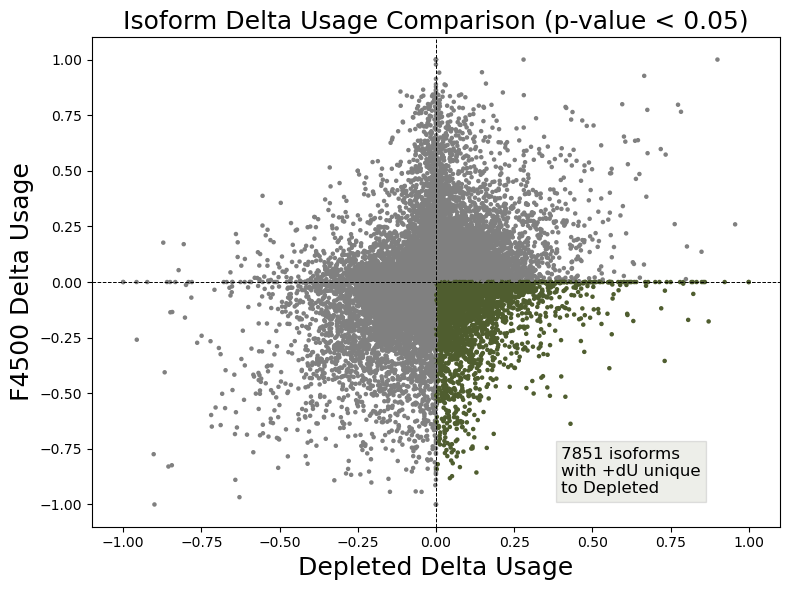

In [ ]:
#scatter plot of standard_dU vs depleted_dU
plt.figure(figsize=(8,6))
plt.scatter(reduced['depleted_dU'], reduced['standard_dU'], s=5,
            c=np.where((reduced['depleted_dU']>0) & (reduced['standard_dU']<0.001), "#4F5D2F", 'grey'))

num_green = sum((reduced['depleted_dU']>0) & (reduced['standard_dU']<0.001))
plt.text(0.4, -0.95, str(num_green) + " isoforms\nwith +dU unique\nto Depleted", 
        fontsize = 12, 
        bbox = dict(facecolor = "#4F5D2F", alpha = 0.1))
plt.xlabel('Depleted Delta Usage', fontsize=18)
plt.ylabel('F4500 Delta Usage', fontsize=18)
plt.title('Isoform Delta Usage Comparison (p-value < 0.05)', fontsize=18)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/isoform_deltaUsage_F4500_DEH.png', dpi=300)
plt.show()

In [242]:
#these are the genes uniquely and significantly enriched in depleted versus standard
selected = reduced[(reduced['depleted_dU']>0) & (reduced['standard_dU']<0.001)]
selected['isoform'] = selected.index
selected['isoform_stable_id'] = selected['isoform'].str.split('.').str[0]
selected = selected.set_index('isoform_stable_id')
selected 

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_13967/3222974320.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['isoform'] = selected.index
/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_13967/3222974320.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['isoform_stable_id'] = selected['isoform'].str.split('.').str[0]


,standard_padj,depleted_padj,standard_dU,depleted_dU,standard_pvalue,depleted_pvalue,isoform
isoform_stable_id,,,,,,,
ENST00000382745,0.117928,0.086061,-0.262434,0.119356,0.027280,0.022274,ENST00000382745.9
ENST00000681291,0.100030,0.051987,-0.010769,0.024024,0.018793,0.008114,ENST00000681291.1
ENST00000489544,0.182244,0.044767,-0.016817,0.032821,0.063404,0.005786,ENST00000489544.1
ENST00000393512,0.364431,0.019722,-0.045983,0.110476,0.205549,0.000720,ENST00000393512.7
ENST00000475157,0.808603,0.014926,0.000214,0.292238,0.706666,0.000215,ENST00000475157.1
...,...,...,...,...,...,...,...
ENST00000287706,0.138498,0.795602,-0.164980,0.015556,0.038178,0.698291,ENST00000287706.8
ENST00000676683,0.129039,0.967784,-0.081513,0.001702,0.032998,0.947006,ENST00000676683.1
ENST00000414030,0.148891,0.963304,-0.057987,0.001044,0.044094,0.939531,ENST00000414030.6


In [ ]:
#add the gene name and save for Enrichr GSEA
#these are the genes uniquely and significantly enriched in depleted
conversion_table = pd.read_csv('Ensembl_Conversion_Table_GeneName_ID.txt', delimiter='\t')
conversion_table = conversion_table.set_index('Transcript stable ID')

selected = selected.join(conversion_table[['Gene name']], how='left')

genes = selected[selected['depleted_padj']<0.05]
genes = selected[selected['depleted_dU']>0.1]
genes = genes['Gene name'].unique().tolist()
genes = [gene for gene in genes if pd.notna(gene)]
print(len(genes))

#save as tab delimited text file 
with open('GREGOR_GUIDE/figures/DTU_unique_isoform_genes_from_depleted.txt', 'w') as f:
    for gene in genes:
        f.write(gene + '\n')

In [ ]:
#these are the genes uniquely and significantly enriched in standard
selected = reduced[(reduced['standard_dU']>0) & (reduced['depleted_dU']<0.001)]
selected['isoform'] = selected.index
selected['isoform_stable_id'] = selected['isoform'].str.split('.').str[0]
selected = selected.set_index('isoform_stable_id')

selected = selected.join(conversion_table[['Gene name']], how='left')

genes = selected[selected['standard_padj']<0.05]
genes = selected[selected['standard_dU']>0.1]
genes = genes['Gene name'].unique().tolist()
genes = [gene for gene in genes if pd.notna(gene)]
print(len(genes))

#save as tab delimited text file 
with open('GREGOR_GUIDE/figures/DTU_unique_isoform_genes_from_standard.txt', 'w') as f:
    for gene in genes:
        f.write(gene + '\n')

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_13967/1205212887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['isoform'] = selected.index
/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_13967/1205212887.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['isoform_stable_id'] = selected['isoform'].str.split('.').str[0]


1849


In [ ]:
def plot_enrichment_lollipop(df: pd.DataFrame, 
                             top_n=10, 
                             title="Top Enriched Terms",
                             save=False,
                             savefile="GREGOR_GUIDE/figures/enrichment_lollipop.png"):
    """
    Lollipop chart for enrichment results with:
      - X: -log10(Adjusted P-value)
      - Y: Term
      - Dot size: Overlap Count
      - Dot color: P-value (light green = most significant)
      - Right-side: colorbar (P-value) + bubble size legend (10/100/200 genes)
    """

    # --- Check columns ---
    required_cols = ["Term", "Overlap", "P-value", "Adjusted P-value"]
    if not all(c in df.columns for c in required_cols):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    # Parse "157/796" → 157
    df = df.copy()
    df["Overlap Count"] = df["Overlap"].str.split("/").str[0].astype(int)

    # Select top terms (lowest adjusted p-value)
    top_df = df.nsmallest(top_n, "Adjusted P-value").iloc[::-1]  # reverse for top-down plotting

    # --- Colormap setup ---
    cmap = mpl.cm.Greens_r  # reversed so lowest p-value = lightest green
    vmin, vmax = top_df["P-value"].min(), top_df["P-value"].max()
    if vmin == vmax:
        vmax = vmin + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(4, 0.4 * top_n), dpi=150)
    y_positions = np.arange(len(top_df))

    # X metric
    top_df["-log10 Adj P"] = -np.log10(top_df["Adjusted P-value"])

    # Lollipop stems
    ax.hlines(y=y_positions, xmin=0, xmax=top_df["-log10 Adj P"],
              color="lightgray", lw=2, zorder=1)

    # Size scaling (reused for legend bubbles)
    def size_scale(n_genes):  # same mapping as scatter
        return np.sqrt(n_genes) * 20

    # Scatter points
    sc = ax.scatter(
        top_df["-log10 Adj P"],
        y_positions,
        s=size_scale(top_df["Overlap Count"]),
        c=top_df["P-value"],
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    # --- Axes formatting ---
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_df["Term"], fontsize=11)
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=13)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=15, pad=15)

    # Give a bit of right margin for the two right-side scales
    plt.subplots_adjust(right=0.78)

    # --- Right-side colorbar (P-value) ---
    cax = inset_axes(ax, width="3%", height="55%",
                     loc="center left",
                     bbox_to_anchor=(1.1, 0.12, 1, 1),
                     bbox_transform=ax.transAxes,
                     borderpad=0)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("P-value", fontsize=11, rotation=270, labelpad=12)
    cbar.ax.invert_yaxis()  
    cbar.ax.tick_params(labelsize=9)

    # --- Bubble size legend (10, 100, 200 genes), stacked under colorbar ---
    sax = inset_axes(ax, width="16%", height="28%",
                     loc="lower left",
                     bbox_to_anchor=(1.01, -0.3, 1, 1.8),
                     bbox_transform=ax.transAxes,
                     borderpad=0)

    sax.set_xlim(0, 1)
    sax.set_ylim(0, 1)
    sax.axis("off")

    # Positions for bubbles and labels
    bubble_vals = [200, 100, 10]  
    ys = [0.7, 0.45, 0.2]
    x_bub = 0.35
    x_txt = 0.68

    for y, v in zip(ys, bubble_vals):
        sax.scatter(x_bub, y, s=size_scale(v),
                    facecolor="lightgray", edgecolor="black", linewidth=0.5)
        sax.text(x_txt, y, f"{v}", va="center", ha="left", fontsize=9)

    sax.text(0.0, 0.95, "Overlap size", fontsize=10)

    # --- Styling ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    if save:
        plt.savefig(savefile, dpi=400, bbox_inches="tight")

    plt.show()

    return top_df

In [4]:
data = pd.read_csv('NEW_guide_analysis_GREGOR/gsea/ClinVar_2025_table.txt', delimiter='\t')
data = data.sort_values(by='Adjusted P-value', ascending=True)
data.head(10)

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GLOBAL DEVELOPMENTAL DELAY,29/131,0.000005,0.002023,0,0,2.878637,35.133274,KMT2E;DDX3X;ANKRD11;HEXA;PTEN;SLC2A1;ATP1A3;CH...
1,INTELLECTUAL DISABILITY,68/497,0.000409,0.082519,0,0,1.611031,12.570873,WASHC4;KDM5C;DDX3X;FMR1;DOCK8;HEXA;PTEN;SLC2A1...
2,ABNORMAL CENTRAL MOTOR FUNCTION,5/10,0.001045,0.140675,0,0,10.044199,68.944469,SPAST;GCH1;SACS;ANO10;SPG11
3,SPASTIC PARAPARESIS,4/8,0.003509,0.227721,0,0,10.039205,56.746084,SPAST;PSEN1;SPG7;SPG11
4,HEREDITARY SPASTIC PARAPLEGIA,15/77,0.003526,0.227721,0,0,2.435887,13.756996,FANCI;USP8;ARL6IP1;VPS37A;SPG7;PHF6;GBA2;HSPD1...
5,IMMUNODEFICIENCY,15/77,0.003526,0.227721,0,0,2.435887,13.756996,IFNAR2;FANCI;IVNS1ABP;CD81;STAT1;IRAK4;PIK3R1;...
6,LEUKODYSTROPHY,6/18,0.003946,0.227721,0,0,5.022941,27.802675,ARSA;UFM1;EPRS1;HEXA;ERCC2;DEGS1
11,PROGRESSIVE EXTERNAL OPHTHALMOPLEGIA,4/11,0.013252,0.411838,0,0,5.735742,24.799001,FANCI;DGUOK;TOP3A;TK2
10,RETINAL DYSTROPHY,34/252,0.012623,0.411838,0,0,1.573382,6.879193,INVS;CERKL;SLC24A1;PANK2;UBR2;AHR;RNF7;SPG7;ME...
12,FRONTOTEMPORAL DEMENTIA,4/11,0.013252,0.411838,0,0,5.735742,24.799001,ARSA;MEF2C;PSEN1;TARDBP


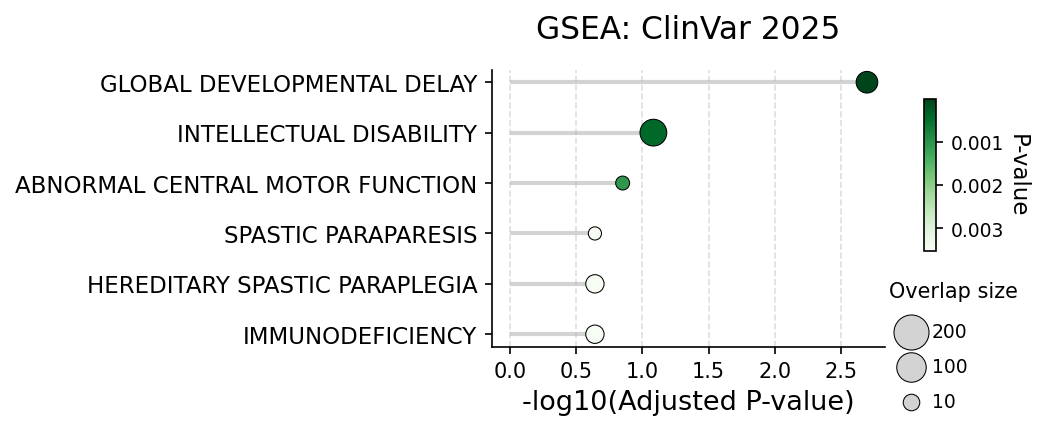

In [368]:
top_df = plot_enrichment_lollipop(data, top_n=6, title="GSEA: ClinVar 2025", save=True, 
                                 savefile="GREGOR_GUIDE/figures/ClinVar_enrichment_lollipop.png")

In [369]:
data = pd.read_csv('NEW_guide_analysis_GREGOR/gsea/GO_Biological_Process_2025_table.txt', delimiter='\t')
data = data.sort_values(by='Adjusted P-value', ascending=True)
#shorten for go biological process
data.at[2, 'Term'] = "RNA Splicing, via Transesterification (GO:0000377)"
data.head(10)

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,"mRNA Splicing, via Spliceosome (GO:0000398)",50/211,1.830828e-10,7.008158e-07,0,0,3.171397,71.106151,DDX46;EIF4A3;HNRNPU;PPWD1;WDR83;EFTUD2;SYNCRIP...
1,Protein Ubiquitination (GO:0016567),72/369,3.412787e-10,7.008158e-07,0,0,2.487943,54.232984,RNF13;UBE2D2;FBXO28;UBE2D3;ARRB1;DDA1;NUB1;RUS...
2,"RNA Splicing, via Transesterification (GO:0000...",42/171,1.620200e-09,2.218054e-06,0,0,3.315678,67.111703,DDX5;DDX46;EIF4A3;HNRNPU;PPWD1;WDR83;SNU13;C9O...
3,mRNA Processing (GO:0006397),50/226,2.297088e-09,2.358535e-06,0,0,2.898693,57.659711,TCERG1;DDX46;EIF4A3;HNRNPU;PPWD1;WDR83;EFTUD2;...
4,Proteasomal Protein Catabolic Process (GO:0010...,67/372,3.916446e-08,3.216969e-05,0,0,2.246990,38.323521,UBXN1;UBE2D3;ARRB1;HERPUD1;PSMD8;PSMD7;TRIM3;P...
5,Chromatin Remodeling (GO:0006338),52/262,5.338606e-08,3.654276e-05,0,0,2.524647,42.277019,LIN54;SUV39H2;KDM5C;RSF1;CHD3;VPS72;DPF2;PWWP2...
6,Modification-Dependent Protein Catabolic Proce...,43/208,2.290404e-07,1.343813e-04,0,0,2.650181,40.519595,VCP;RNF13;UHRF1;UBE2D2;UBE2D3;NEDD8;FBXO45;ARR...
7,Ubiquitin-Dependent Protein Catabolic Process ...,75/455,2.679907e-07,1.375797e-04,0,0,2.019623,30.561575,UBXN1;RNF13;UBE2D2;UBE2D3;TNFAIP3;ARRB1;FBXO21...
8,Protein Modification by Small Protein Conjugat...,57/316,3.776854e-07,1.723505e-04,0,0,2.244087,33.188255,UBE2D2;UBE2D3;ARRB1;NUB1;CDC27;RACK1;TRIM27;AR...
9,Gene Expression (GO:0010467),65/381,4.809256e-07,1.975162e-04,0,0,2.100335,30.554728,RPL4;MRPS15;SMG1;RPL3;RPL32;MRPS11;FMR1;EIF4A3...


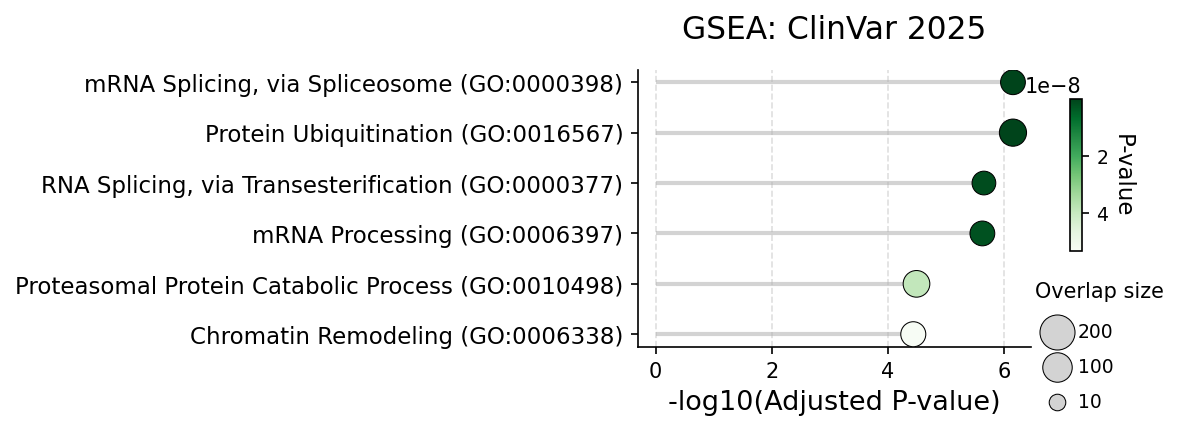

In [370]:
top_df = plot_enrichment_lollipop(data, top_n=6, title="GSEA: ClinVar 2025", save=True, 
                                 savefile="GREGOR_GUIDE/figures/GO_biological_enrichment_lollipop.png")